## Lecture 10

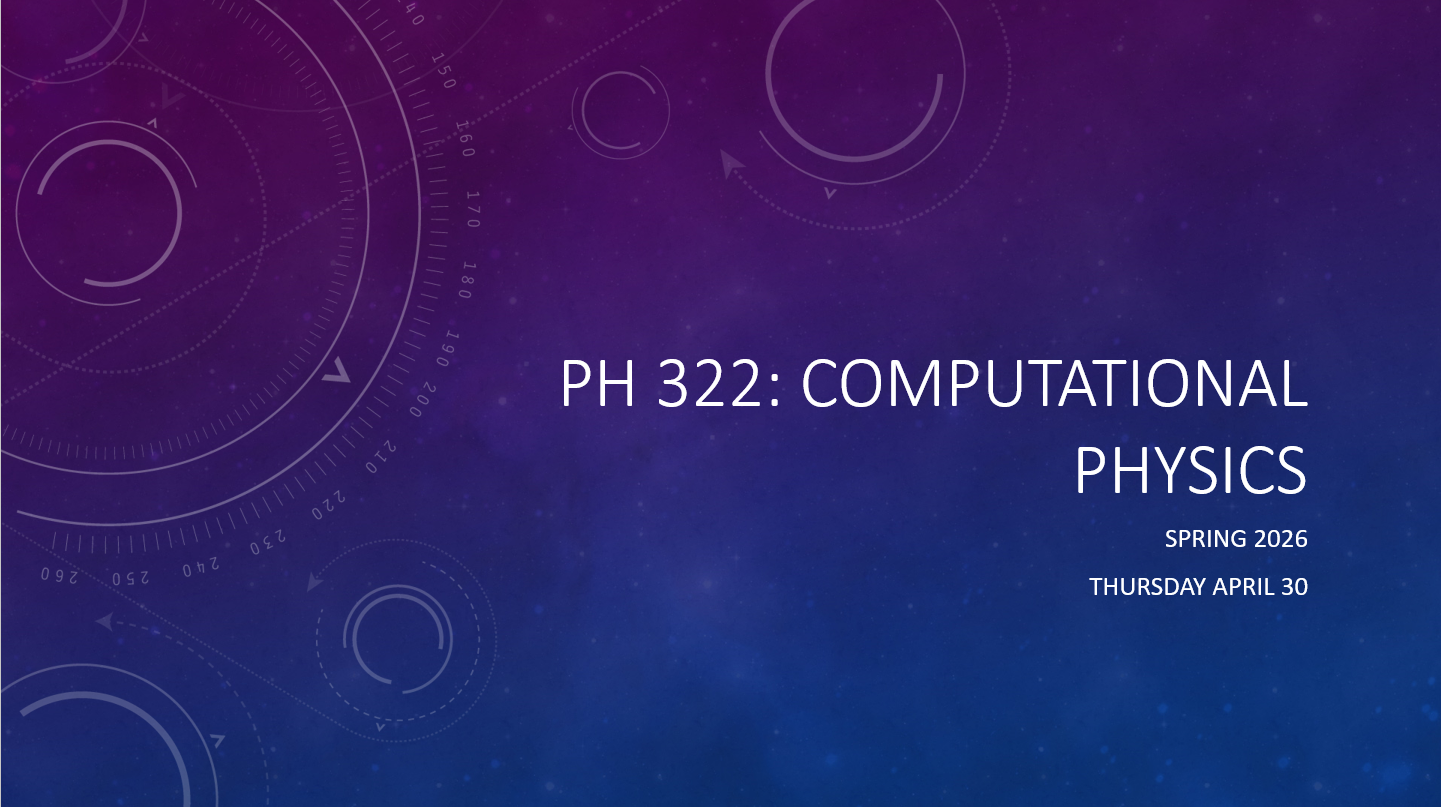

In [1]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture10.png"))

* Midterm is Tuesday. Study guide on Canvas. Bring two sheets of notes.  
* The due date for HW5 is Wednesday.
  

**Last Class**

* Numerical derivatives
* Forward, backward, and central difference methods
* Approximation and rounding errors on numerical derivatives
* Second derivatives
* Partial derivatives
* Calculating derivatives of numerical data

**Today's Class**
* Solving non-linear equations
    * The relaxation method
    * Binary search method
    * Newton's method


## Solving non-linear equations

It is common in physics to encounter non-linear equations. 

For example the van der Waals equation of state

$$
(P+\frac{a}{v^2})(v-b)=RT
$$

is cubic in the volume $v$, which can not be solved analytically.

When solving the one-dimensional quantum mechanical finite square well problem, we encounter a transcendental equation of the form

$$
k\tan ka = \kappa
$$

which must be solved graphically. 

In this unit we will learn three different methods we can use to solve nonlinear equations.

* Relaxation method  
* Binary search 
* Newton's method  

No one method works on all functions, so it is good to have a "toolkit" of different methods you can try.


### Relaxation method (also called fixed-point iteration)

Consider the nonlinear equation:

$$
e^{-x} = 2-x,
$$

which has no analytic solution. 


To use the relaxation method we first rearrange our equation to get it into the form:

$$
x=f(x). 
$$

For the equation above, we can do this easily:

$$
x = 2-e^{-x},
$$

or 

$$x=f(x),
$$

where   

$$
f(x)=2-e^{-x}.
$$

The goal is to find $x$ that satisfies this equation. 

Let's plot both sides of the equation vs. $x$  to get some insight into the problem.


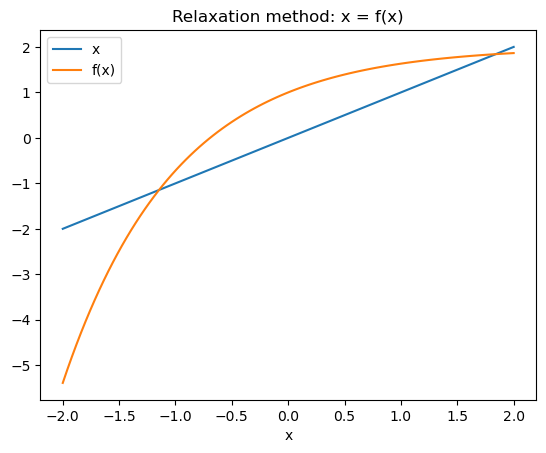

In [21]:
# plot nonlinear function x=2-exp(-x)

import numpy as np
import matplotlib.pyplot as plt

# define function
def f(x):
    return 2-np.exp(-x)

# create values of x from -2 to 2.
xvalues = np.linspace(-2,2,100)

# pass xvalues to f(x)
yvalues = f(xvalues)

# plot f(x) and x vs. x
plt.plot(xvalues, xvalues, label='x')
plt.plot(xvalues, yvalues, label='f(x)')
plt.xlabel("x")
plt.title("Relaxation method: x = f(x)")
plt.legend()
plt.show()


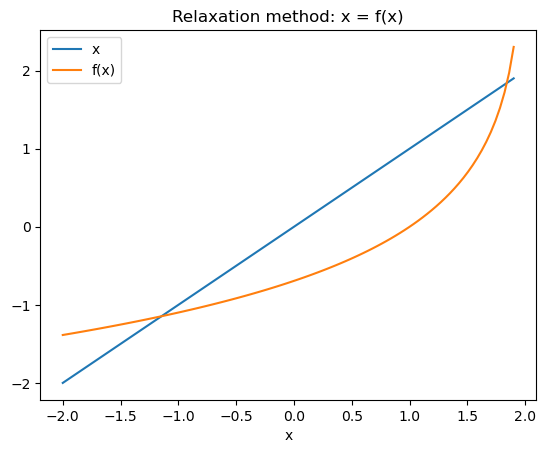

In [16]:
# plot nonlinear function x=2-exp(-x)

import numpy as np
import matplotlib.pyplot as plt

# define function
def f(x):
    return -np.log(2-x)

# create values of x from -2 to 2.
xvalues = np.linspace(-2,1.9,100)

# pass xvalues to f(x)
yvalues = f(xvalues)

# plot f(x) and x vs. x
plt.plot(xvalues, xvalues, label='x')
plt.plot(xvalues, yvalues, label='f(x)')
plt.xlabel("x")
plt.title("Relaxation method: x = f(x)")
plt.legend()
plt.show()


A solution to this equation is where $x$ = $f(x)$. From the graph we see there are two solutions, one is around 1.7. Let's test to see if 1.7 is a solution, by evaluating the function at 1.7.  

In [22]:
# test if 1.7 is a solution

x=1.7

print(f"x={x}  f(x)={f(x)}")

x=1.7  f(x)=1.8173164759472653


We see this isn't a solution, since $f(x)$ does not equal $x$. 

The relaxation method is simply to use $f(x)$ as the next guess for $x$. Let's put $f(x)$ back into the equation.

In [4]:
# second iteration
# need to run previous cell first

x=f(x)

print(f"x={x}  f(x)={f(x)}")

x=1.8173164759472653  f(x)=1.8375388651459923


We see that $x$ and $f(x)$ are getting close.  Let's again put f(x) back into the equation. 

In [5]:
# third iteration
# need to run previous cell first

x=f(x)

print(f"x={x}  f(x)={f(x)}")

x=1.8375388651459923  f(x)=1.840791221402177


Instead of manually iterating through choices, let's code this so the computer does the iterating for us.

We will again make an initial of guess at $x=1.7$ and perform 10 iterations. 

In [6]:
# iterative approach to finding the true solution.

import numpy as np

# repeat the definition of the function here for convenience
def f(x):
    return 2-np.exp(-x)


# number of iterations
N = 10

# initial guess
x = 1.7

# print header.
print(f"{'x':^20}{'f(x)':^20}{'|f(x)-x|':^20}")

# iterate 10 times, each time updating x with f(x)
for i in range(N):
    x = f(x)
    print(f"{x:>15} {f(x):>15} {abs(f(x)-x):>15}")

         x                  f(x)              |f(x)-x|      
1.8173164759472653 1.8375388651459923 0.020222389198726987
1.8375388651459923 1.840791221402177 0.0032523562561848074
1.840791221402177 1.841308183940422 0.0005169625382448473
1.841308183940422 1.8413902004628893 8.201652246730973e-05
1.8413902004628893 1.84140320855363 1.3008090740784795e-05
1.84140320855363 1.8414052715816664 2.063028036403125e-06
1.8414052715816664 1.8414055987667002 3.2718503373274643e-07
1.8414055987667002 1.841405650656406 5.188970586544883e-08
1.841405650656406 1.84140565888582 8.229414039107041e-09
1.84140565888582 1.8414056601909585 1.3051384417650524e-09


You can see with only 10 iterations we're getting pretty close to the true solution. How many iterations does it take to get down to numerical error?

Let's use a while loop to test the difference until we hit this target.

In [28]:
# iterative approach to finding the true solution.

import sys

# repeat the definition of the function here for convenience
def f(x):
    return 2-np.exp(-x)


# get the error constant from the sys package
C = sys.float_info.epsilon

print(C)

# initial guess
x = 1.7
i=1

# calculate the difference between x and f(x)
diff = abs(f(x) - x)

print(f"{'i':^4}{'x':^20}{'f(x)':^20}{'|f(x)-x|':^20}")

# iterate until the difference is less than the rounding error on the difference
while diff > C:
    print(f"{i:^4} {x:^20} {f(x):^20} {diff:^20}")
    x = f(x)
    diff = abs(f(x) - x)
    i += 1
    
solution = x

2.220446049250313e-16
 i           x                  f(x)              |f(x)-x|      
0.11731647594726535 2.220446049250313e-16
 1           1.7           1.8173164759472653  0.11731647594726535 
0.020222389198726987 2.220446049250313e-16
 2    1.8173164759472653   1.8375388651459923  0.020222389198726987
0.0032523562561848074 2.220446049250313e-16
 3    1.8375388651459923   1.840791221402177   0.0032523562561848074
0.0005169625382448473 2.220446049250313e-16
 4    1.840791221402177    1.841308183940422   0.0005169625382448473
8.201652246730973e-05 2.220446049250313e-16
 5    1.841308183940422    1.8413902004628893  8.201652246730973e-05
1.3008090740784795e-05 2.220446049250313e-16
 6    1.8413902004628893    1.84140320855363   1.3008090740784795e-05
2.063028036403125e-06 2.220446049250313e-16
 7     1.84140320855363    1.8414052715816664  2.063028036403125e-06
3.2718503373274643e-07 2.220446049250313e-16
 8    1.8414052715816664   1.8414055987667002  3.2718503373274643e-07
5.18897058

So we see we reach the true solution to within numerical precision with about 20 iterations. Pretty good. 

This technique of iteration is called the **relaxation method**, where you use the value of the function as the next input into the function until the function converges to a fixed value. That will be the solution.



For good measure we will plot the solution:

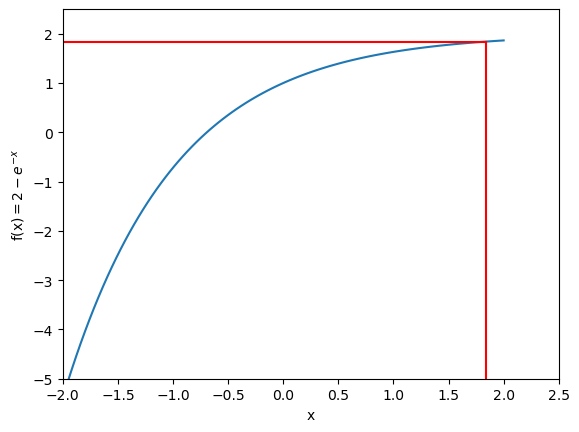

In [5]:
# plot nonlinear function x=2-exp(-x) and its solution

import numpy as np
import matplotlib.pyplot as plt


# define function
def f(x):
    return 2-np.exp(-x)

xvalues = np.linspace(-2,2,100)
yvalues = f(xvalues)

plt.plot(xvalues,yvalues)
plt.plot([solution, solution], [f(-5),f(solution)], 'r-')
plt.plot([-2,solution], [f(solution), f(solution)], 'r-')
plt.xlabel("x")
plt.ylabel(r"f(x)$=2-e^{-x}$")
plt.ylim(-5,2.5)
plt.xlim(-2,2.5)
plt.show()

### Relaxation method and convergence

In this example our initial guess was fairly close to the solution. But what if we don't know in advance what the approximate solution is? 

Let's see how well the relaxation method converges on a solution if our initial guess is far from the solution. 

We will repeat the above example but with an initial guess of 100. 

In [31]:
# relaxation method - initial guess x=100

import sys

# repeat the definition of the function here for convenience
def f(x):
    return 2-np.exp(-x)


# specify target error
C = sys.float_info.epsilon

# initial guess
x = 100
i=1

# calculate the difference between x and f(x)
diff = abs(f(x) - x)

print(f"{'i':^4}{'x':^20}{'f(x)':^20}{'|f(x)-x|':^20}")

# iterate until the difference is less than the rounding error on the difference
while diff > C:
    print(f"{i:^4} {x:^20} {f(x):^20} {diff:^20}")
    x = f(x)
    diff = abs(f(x) - x)
    i += 1
    
solution = x





 i           x                  f(x)              |f(x)-x|      
 1           100                  2.0                  98.0        
 2           2.0           1.8646647167633872   0.1353352832366128 
 3    1.8646647167633872   1.8450518473052135  0.019612869458173643
 4    1.8450518473052135   1.8419828720850022  0.003068975220211323
 5    1.8419828720850022   1.8414971765224537  0.000485695562548516
 6    1.8414971765224537   1.8414201737059899  7.700281646383367e-05
 7    1.8414201737059899   1.8414079621425745  1.221156341535412e-05
 8    1.8414079621425745   1.8414060254740223  1.9366685521937654e-06
 9    1.8414060254740223   1.8414057183297619  3.071442604696273e-07
 10   1.8414057183297619   1.8414056696184309  4.8711330968842503e-08
 11   1.8414056696184309   1.8414056618930899  7.725341033548716e-09
 12   1.8414056618930899   1.8414056606678946  1.2251952785646836e-09
 13   1.8414056606678946   1.8414056604735856  1.9430901332384565e-10
 14   1.8414056604735856   1.8414056604

We see the method still converges on the solution, using about the same number of iterations. 

Let's try to find the other solution which from the previous graph looks to be around -1.2.

In [34]:
# relaxation method - initial guess x=-1.2

import sys

# repeat the definition of the function here for convenience
def f(x):
    return 2-np.exp(-x)


# specify target error
C = sys.float_info.epsilon

# initial guess
x = -1.2
i=1

# calculate the difference between x and f(x)
diff = abs(f(x) - x)

print(f"{'i':^4}{'x':^20}{'f(x)':^20}{'|f(x)-x|':^20}")

# iterate until the difference is less than the rounding error on the difference
while diff > C:
    print(f"{i:^4} {x:^20} {f(x):^20} {diff:^20}")
    x = f(x)
    diff = abs(f(x) - x)
    i += 1
    
solution = x




 i           x                  f(x)              |f(x)-x|      
 1           -1.2         -1.3201169227365472  0.12011692273654728 
 2   -1.3201169227365472  -1.7438590939213574  0.42374217118481017 
 3   -1.7438590939213574  -3.7193724848130394   1.975513390891682  
 4   -3.7193724848130394   -39.23850819737756   35.51913571256452  
 5    -39.23850819737756  -1.0991768884559003e+17 1.0991768884559e+17 
 6   -1.0991768884559003e+17         -inf                 inf         


C:\Users\cbuten\AppData\Local\Temp\ipykernel_38616\548216899.py:7: RuntimeWarning: overflow encountered in exp
  return 2-np.exp(-x)
C:\Users\cbuten\AppData\Local\Temp\ipykernel_38616\548216899.py:26: RuntimeWarning: invalid value encountered in scalar subtract
  diff = abs(f(x) - x)


Interesting. What's happening for $x=-1.2$? 

We quickly diverge from the solution to the point where the difference between $x$ and $f(x)$ becomes so large it is a float overflow, with only 6 iterations! Clearly $f(x)$ did not converge to a fixed value. 

So why did the iterative process blow up at $x=-1.2$ pushing $x$ to exponentially large negative numbers?


Did you guess that we'll need to use a Taylor series expansion to find out?



### Taylor series expansion of f(x) around the solution

To investigate the behavior of the relaxation method around the solution, we expand $f(x)$ about the solution, call it $x^*$.

$$
f(x) = f(x^*) + f'(x^*)(x-x^*) + \text{higher order terms which we ignore}
$$

Since at the solution ,$f(x^*)=x^*$, we can write this as:

$$
f(x) = x^* + f'(x^*)(x-x^*)  
$$

Let's call our first guess of the solution, $x^0$. After an iteration of the relaxation method, what we get out --- call it $x^1$ ---- is $f(x^0)$, so:

$$
x^1 = f(x^0) = x^* + f'(x^*)(x^0-x^*)  
$$

And if we subtract $x^*$ from both sides of the equation:  

$$
\underbrace{x^1 - x^*}_{\text{error in current estimate}} =  f'(x^*)\underbrace{(x^0-x^*)}_{\text{error in previous estimate}}
$$

This now allows us to compare how close the current iteration $𝑥^1$ is to the solution, compared to the previous iteration $𝑥^0$. 

In order for the relaxation method to converge on the solution, we want each iteration to be closer to the solution than the previous solution. 

But this result tells us it depends on the derivative of $f(x)$ evaluated at $𝑥^∗$. If $|f'(x^*)| <1$ then each iteration will bring us closer to the solution. However if  $|f'(x^*)| > 1$ then each iteration will bring us farther from it.

Let's calculate $f'(x^*)$ at the first solution we found, $x \sim 1.8414$.

$$
f(x) = 2-e^{-x}
$$

$$
f'(x) = e^{-x}
$$

$$
f'(1.8414) = 0.16
$$

This result tells us that the relaxation method will converge to the solution for, at least choices of $x$ near the solution (since we did the expansion of $f(x)$ around $x^*$). So this explains why we could get the true solution when we started with an initial guess of $x=1.7$. 

However, if our initial guess is far from the solution, the relaxation method may not converge. The relaxation method is not guaranteed to converge even if the derivative is less than 1 at the solution. It is good to know approximately what the solution is. Graphing your function first often helps.



In sum,  the *minimum* condition for the relaxation method to converge is that the absolute value of the derivative evaluated at the solution must be less than 1. 

### What to do if the derivative is greater than 1?

What is $f'(x^*)$ at the second solution, which occurs around -1.2?

$$
f'(-1.2) = 3.32
$$

This explains why the relaxation method didn't converge with an initial guess of -1.2.

In this case it is sometimes possible to cast the equation in a different form, and try the relaxation method on the new form of the equation. For example, we can invert our equaton to get a different $f(x)$.

Our original equation is

$$
x = 2-e^{-x}.
$$

Solve for $x$ in the right-hand side of equation:

$$
e^{-x} = 2-x,
$$

$$
-x = \log(2-x),
$$,

$$
x = -\log(2-x).
$$

So now:
$$
x = f(x),
$$

where $f(x) = -\log(2-x)$.

Take the derivative of this new function and evaluate it at -1.2.

$$
f'(x) = \frac{1}{2-x},
$$

and 

$$
f'(-1.2) = 0.3125
$$

Now the derivative at the solution is less than 1, so it meets the minimum convergence criterion of the relaxation method.

Let's first plot the new $f(x)$ to verify it preserves the locations of the solutions. 



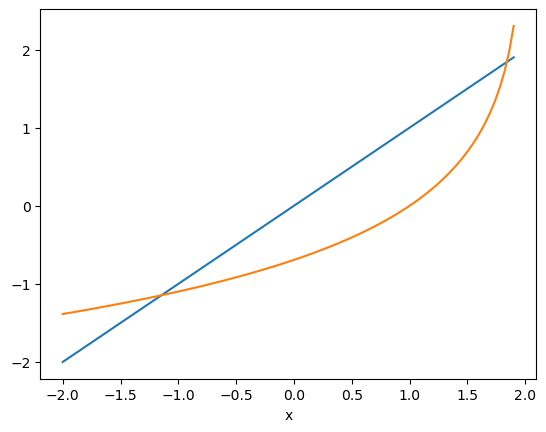

In [19]:
# plot f(x) = -log(2-x)

import numpy as np
import matplotlib.pyplot as plt


# define function
def f(x):
    return -np.log(2-x) 

xvalues = np.linspace(-2,1.9,100)
yvalues = f(xvalues)

plt.plot(xvalues,xvalues)
plt.plot(xvalues,yvalues)
plt.xlabel("x")
plt.show()


Now we will test if it converges using an initial guess of -1.2.

In [33]:
# relaxation method - recast the original equation as: f(x) =log(2-x)

import sys
import numpy as np


# define function
def f(x):
    return -np.log(2-x)  
    
# get error constant
C = sys.float_info.epsilon

# initial guess
x = -1.2
i=1

# calculate the difference between x and f(x)
diff = abs(f(x) - x)

print(f"{'i':^4}{'x':^20}{'f(x)':^20}{'|f(x)-x|':^20}")

# iterate until the difference is less than the rounding error on the difference
while diff > C:
    print(f"{i:^4} {x:^20} {f(x):^20} {diff:^20}")
    x = f(x)
    diff = abs(f(x) - x)
    i += 1
    
solution = x


 i           x                  f(x)              |f(x)-x|      
 1           -1.2         -1.1631508098056809  0.03684919019431909 
 2   -1.1631508098056809  -1.1515686225437263  0.01158218726195459 
 3   -1.1515686225437263  -1.1479003042996407  0.0036683182440855333
 4   -1.1479003042996407  -1.1467356605173389  0.0011646437823018552
 5   -1.1467356605173389  -1.1463656172607943  0.00037004325654454995
 6   -1.1463656172607943  -1.1462480144317162  0.00011760282907813391
 7   -1.1462480144317162  -1.1462106363767537  3.737805496251134e-05
 8   -1.1462106363767537  -1.1461987561064055  1.1880270348152422e-05
 9   -1.1461987561064055   -1.146194980042387  3.776064018579106e-06
 10   -1.146194980042387  -1.1461937798428519  1.2001995350896522e-06
 11  -1.1461937798428519  -1.1461933983662518  3.814766000864722e-07
 12  -1.1461933983662518  -1.1461932771160523  1.2125019943631798e-07
 13  -1.1461932771160523   -1.146193238577353  3.853869934289378e-08
 14   -1.146193238577353   -1.14619

Now the relaxation method does converge on the solution. 

In general if we have an equation:

$
x=f(x)
$

and 

$
f'(x^*)>1
$

then if we invert the equation to get

$
x=f^{-1}(x)
$

like we did above,

then 

$
f'^{-1}(x^*) < 1
$

so the relaxation method will work.

You can not always solve a nonlinear equation with the relaxation method, but it works for many cases and many more where the equation can be easily transformed or inverted. 



### Error estimate of the relaxation method

We can get an estimate of the error on each iteration of $x$ by using the Taylor series expansion of $f(x)$ around the true solution $x^*$ that we used before. For convenience I repeat the expansion here:

$$
x'-x^*=(x-x^*)f'(x^*)
$$

where $x'$ is the value of $f(x)$ after an iteration of the relaxation method using a guess of $x$.

We define errors $\epsilon$ and $\epsilon'$ as:

$$
x^* = x+\epsilon \rightarrow   x - x^* = -\epsilon, 
$$

and

$$
x^* = x'+\epsilon' \rightarrow   x'- x^*= -\epsilon'.
$$

Substituting these in the above equation  

$$
-\epsilon' =-\epsilon f'(x^*),
$$

or:

$$
\epsilon=\frac{\epsilon'}{f'(x^*)}.
$$

Setting the two equations above for $x^*$ equal

$$
x+\epsilon = x'+\epsilon',
$$

and substituting for $\epsilon$, 

$$
x+\frac{\epsilon'}{f'(x^*)}= x'+\epsilon'.
$$

Solving for $\epsilon'$ 

$$
\epsilon'=\frac{x-x'}{1-1/f'(x^*)}.
$$

Since $f'(x^*) \sim f'(x)$ when $x$ is near the solution $x^*$,

$$
\boxed{\epsilon' \sim \frac{x-x'}{1-1/f'(x)}} 
$$

**This is the error on estimate $x'$.**

This says we can calculate the error using the current estimate of the solution, $x'$ and the iteration before, $x$, along with the evaluation of the derivative at $x$. These are all values we know. 

Let's go ahead and calculate the error using $f(x) = 2-e^{-x}$ from our previous example.

In [37]:
# relaxation method - calculate error on each iteration  

import sys
import numpy as np


# define the function 
def f(x):
    return 2-np.exp(-x) 

# define the derivative of the function
def fp(x):
    return -np.exp(-x)
    
# get error constant
C = sys.float_info.epsilon

# initial guess
x = 0.75
i=1

# initialize the error to be big
error = 999.99

# iterate until the error is less than the rounding error 
while error > C:
    xp = f(x)
    error = abs( (x-xp)/(1-1/fp(x)))
    x = xp
    print(f"x={xp:0.10f}  error={error:0.7e}")
    

x=1.5276334473  error=2.4948137e-01
x=1.7829512828  error=4.5533435e-02
x=1.8318588179  error=7.0397062e-03
x=1.8398843349  error=1.1076576e-03
x=1.8411642032  error=1.7542512e-04
x=1.8413673621  error=2.7815225e-05
x=1.8413995864  error=4.4111807e-06
x=1.8414046971  error=6.9958436e-07
x=1.8414055077  error=1.1095002e-07
x=1.8414056362  error=1.7596043e-08
x=1.8414056566  error=2.7906327e-09
x=1.8414056598  error=4.4257855e-10
x=1.8414056603  error=7.0190444e-11
x=1.8414056604  error=1.1131811e-11
x=1.8414056604  error=1.7654402e-12
x=1.8414056604  error=2.7999510e-13
x=1.8414056604  error=4.4406518e-14
x=1.8414056604  error=7.0211538e-15
x=1.8414056604  error=1.1246004e-15
x=1.8414056604  error=1.8236763e-16


### Practice Exercise: Relaxation method

In a physics lab problem, a projectile launcher is mounted a distance $y_0$ above the table. The range of the projectile launched with angle $\theta$ and initial velocity $v_0$ is given by:

$$
x = \frac{v_0 \cos\theta}{g}\left[v_0 \sin\theta + \sqrt{v^2_0 \sin^2\theta + 2y_0 g}\right]
$$

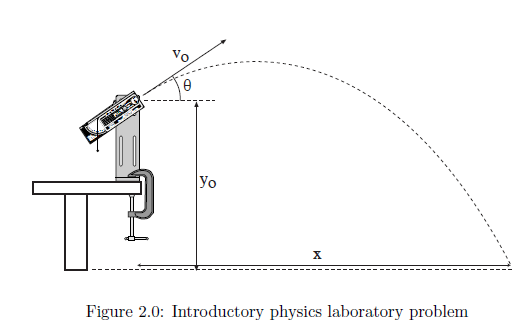


For $v_0=30$ m/s, $y_0=1$ m, use the relaxation method to determine the approximate angle required for a range of $25$m. Test your solution by inserting it into the range equation. 

Hint: Is the range equation in the correct form? If not, you will need to rearrange it. 

 

Solution = 1.43 rad or 82.14 degrees. 
Iterations = 12.
Range = 25.00.


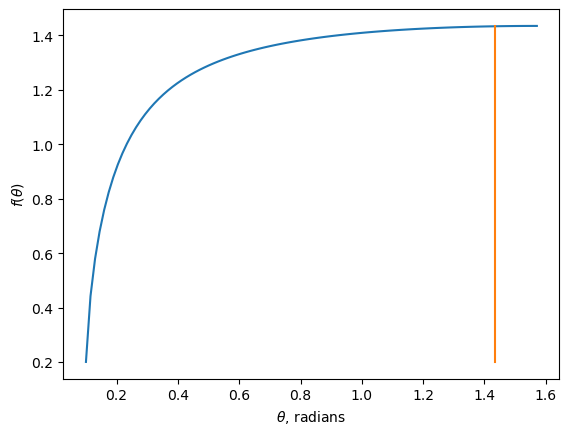

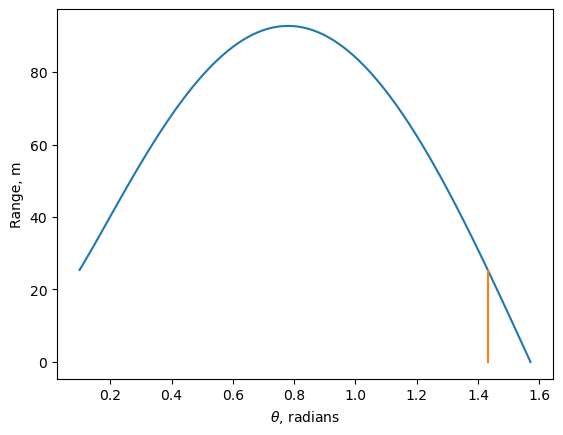

In [38]:
# practice exercise - relaxation method for range equation
# rearrange equation to get it into form: theta = f(theta)
# For most ranges, there will be two solutions (two launch angles). The method will converge only on the higher angle.



## Binary search method

The binary search method is a second method we can use to find the solution to non-linear equations with no analytical solutions.

Unlike the relaxation method, binary search *will* always converge and find a solution, *if* we can bracket the solution correctly. 

To use the binary search method we first rewrite our equation so that all terms are on one side of the equals sign, i.e. 

$$
f(x)=0,
$$

e.g.:

$$
x = e^{1-x^2} 
$$

$$
\rightarrow x-e^{1-x^2} = 0.
$$

Therefore, $f(x) = x-e^{1-x^2}$.

In this form the solutions to the equations are just roots of the function $f(x)$, i.e. values of $x$ that make $f(x)=0$.  So the binary search method is really a method that finds the roots of functions.

Let's plot the above function $f(x)$ first to see what it looks like:

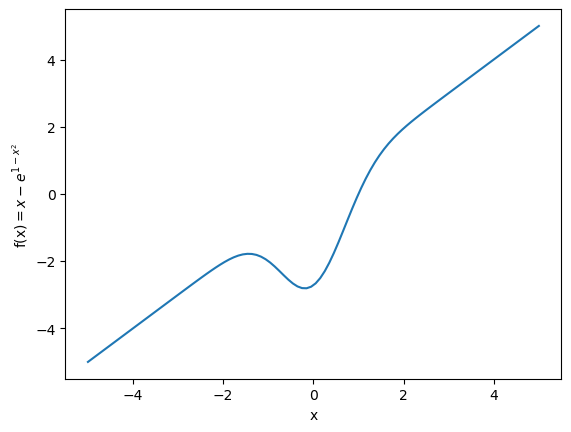

In [3]:
# plot nonlinear function x-exp(1-x^2)

import numpy as np
import matplotlib.pyplot as plt


# define function
def f(x):
    return x-np.exp(1-x**2)

xvalues = np.linspace(-5,5,100)
yvalues = f(xvalues)

plt.plot(xvalues,yvalues)
plt.xlabel("x")
plt.ylabel(r"f(x)$=x-e^{1-x^2}$")
plt.show()


We see the function has both negative and positive values and of course is zero somewhere in between. The value of $x$ where $f(x)=0$ is the *root*. 

The gist of the binary search is that we initially choose an interval $(x_1, x_2)$ that we think brackets the root of the equation.

So let's say in this case we choose an interval of (-2,2) as shown below:

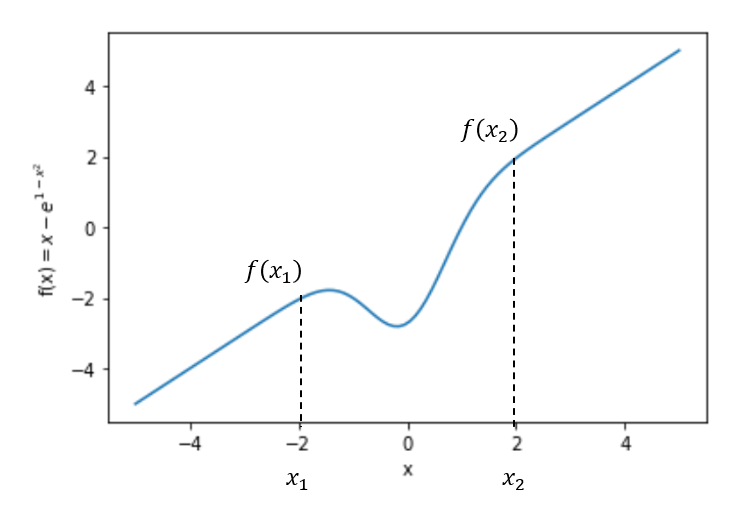

We then evaluate the function at both of these points, $f(x_1)$ and $f(x_2$). If $f(x_1)$ and $f(x_2$) have opposite signs, as they do here, we know the root lies in between them, so we narrow our interval until we find it. 

In the next iteration of the binary search we evaluate the function halfway in between $x_1$ and $x_2$ as shown below.


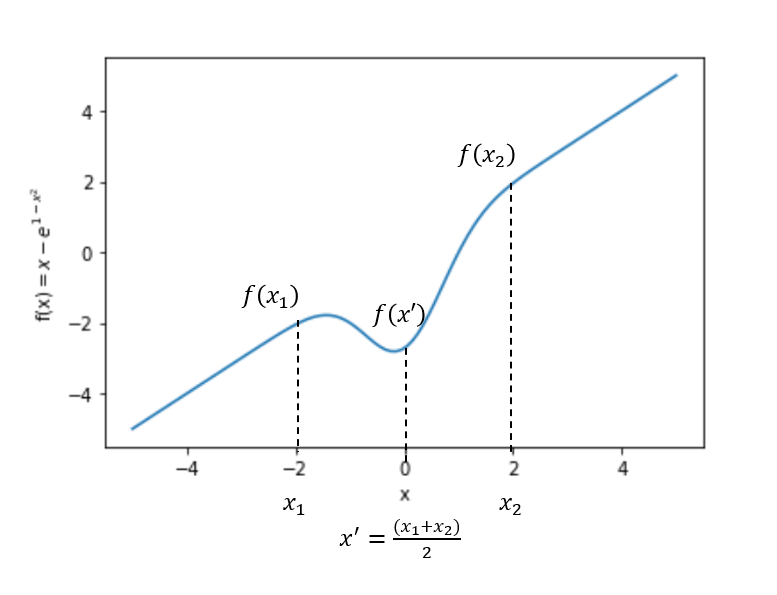

We compare $f(x')$ with $f(x_1)$ and $f(x_2)$. If $f(x')$ is negative and $f(x_2)$ is positive say, then we know the root lies between $x'$ and $x_2$ and we continue searching between those two points. 

If on the other hand $f(x')$ is positive, then we know the root lies between $x'$ and $x_1$ and we continue the search there.  We repeat this process, every time halving the size of our interval until we eventually converge on the root to the accuracy we wish.

The algorithm for the binary search is straightforward. Here is the pseudocode:

1. Choose a target accuracy for your solution.
2. Given an initial pair of points $x_1$, $x_2$, check if $f(x_1)$ and $f(x_2$) have opposite signs. If they don't, increase the bracket. 
3. Calculate the midpoint $x'=\frac{1}{2}(x_1+x_2)$ and evaluate $f(x')$.
4. If $f(x')$ has the same sign as $f(x_1)$ then set $x_1=x'$. Otherwise set $x_2=x'$.
5. If $|x_1-x_2|$ is greater than the target accuracy, repeat from step 3. Otherwise, calculate $\frac{1}{2}(x_1+x_2)$ once more and this is the final estimate of the root.

Note, you can use the numpy function *sign()* to get the sign of a variable. The sign function returns -1 if x < 0, 0 if x==0, and 1 if x > 0.  More information is here:

https://numpy.org/doc/stable/reference/generated/numpy.sign.html

### Practice Exercise: Binary Search

Write a function to perform the binary search method to find the root of a function. Test your function by again finding the launch angle in the range equation above and the same initial conditions. 

Hint: Rearrange the range equation to get it into the right form to perform binary search. You may wish to first plot the function to define the initial bracket. 

**Rearranged equation:**

$$
0 = -x + \frac{v_0 \cos\theta}{g}\left[v_0 \sin\theta + \sqrt{v^2_0 \sin^2\theta + 2y_0 g}\right]
$$

$$
f(\theta) = 0
$$

where

$$
f(\theta) = -x + \frac{v_0 \cos\theta}{g}\left[v_0 \sin\theta + \sqrt{v^2_0 \sin^2\theta + 2y_0 g}\right]
$$

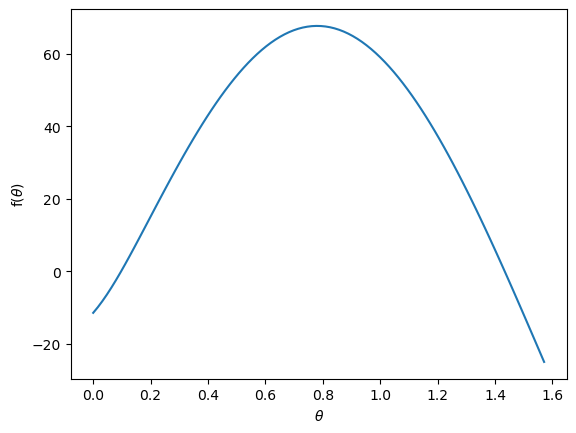

In [37]:
# rearrange equation so f(theta) = 0.
# plot f(theta).




In [40]:
# use binary search to find root of function f(x) 



The bracket (0.4, 1) is to the right of the root. Re-enter x1.


x1:  0


Iteration=0. Interval=(0.0,0.5). Error=5.00e-01.
Iteration=1. Interval=(0.0,0.25). Error=2.50e-01.
Iteration=2. Interval=(0.0,0.125). Error=1.25e-01.
Iteration=3. Interval=(0.0625,0.125). Error=6.25e-02.
Iteration=4. Interval=(0.09375,0.125). Error=3.12e-02.
Iteration=5. Interval=(0.09375,0.109375). Error=1.56e-02.
Iteration=6. Interval=(0.09375,0.1015625). Error=7.81e-03.
Iteration=7. Interval=(0.09375,0.09765625). Error=3.91e-03.
Iteration=8. Interval=(0.095703125,0.09765625). Error=1.95e-03.
Iteration=9. Interval=(0.0966796875,0.09765625). Error=9.77e-04.
Iteration=10. Interval=(0.09716796875,0.09765625). Error=4.88e-04.
Iteration=11. Interval=(0.09716796875,0.097412109375). Error=2.44e-04.
Iteration=12. Interval=(0.09716796875,0.0972900390625). Error=1.22e-04.
Iteration=13. Interval=(0.09722900390625,0.0972900390625). Error=6.10e-05.
Iteration=14. Interval=(0.09722900390625,0.097259521484375). Error=3.05e-05.
Iteration=15. Interval=(0.09722900390625,0.0972442626953125). Error=1.53e

The binary search finds the root down rounding error in about 50 iterations. 

Let's also see what happens if the initial interval doesn't bracket the root. Change the interval above to be (0.4,1).

In the code above I first check if the initial guess brackets the root. If it doesn't I have the user re-enter the bracket. 



### Cases when binary search fails

Consider using the binary search method to find the roots of the sine function: 


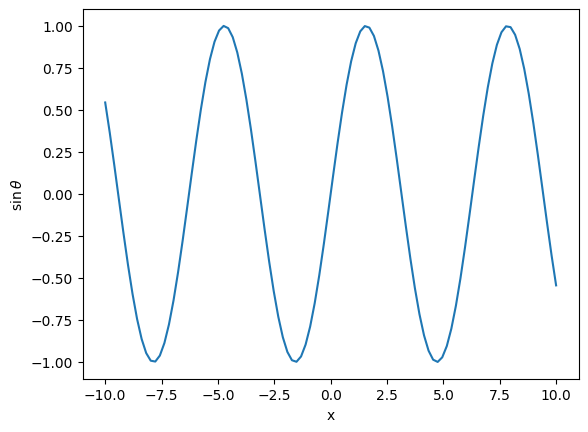

In [3]:
# plot the sin function

import numpy as np
import matplotlib.pyplot as plt


# define function
def f(theta):
    return np.sin(theta)

xvalues = np.linspace(-10,10,100)
yvalues = f(xvalues)

plt.plot(xvalues,yvalues)
plt.xlabel("x")
plt.ylabel(r"$\sin{\theta}$")
plt.show()


Let's use binary search to find the roots. Let's set our initial interval to be (-5, 7.5). Again the binary search should find the values of x where the function is zero. Inspection of the plot shows there are 4 roots in this interval. 

Will the binary search find these?

In [1]:
# use binary search to find roots of sine function

import numpy as np
import matplotlib.pyplot as plt
import sys

# define function
def f(theta):
    return np.sin(theta)


x1=-5
x2=7.5

epsilon = 2e-16
error = x2-x1

# keep track of iterations
i=0

    
print("The root is at {}.".format (root))
print("Iterations = {}".format(i))

NameError: name 'root' is not defined

What happened? 

The binary search here assesses there are no roots, but clearly there are 4 roots bracketed by my interval. 

The problem is easy to see. Because $f(-5)$ and $f(7.5)$ are both positive, the binary search method doesn't think there are any roots in the bracket so the method exits. In general, if there are an even number of roots bracketed by your interval, binary search will fail.

How about an initial interval of (-5, 5)? At the ends of this interval, the function has diffferent signs. Does binary search work now?

In [2]:
# use binary search to find root of sine function

import numpy as np
import matplotlib.pyplot as plt
import sys

# define function
def f(theta):
    return np.sin(theta)


  
print("The root is at {}.".format (root))
print("Iterations = {}".format(i))

NameError: name 'root' is not defined

Now it worked, kind of. It found the root at zero but not the other 2 roots.  So that is another weakness of binary search. It will only find one root of a function even though there might be more, but in some cases you may only need one root.  However, you can always move the interval to find other roots. 

The benefits of the binary search is that it simple and will converge if the bracket includes the root. It doesn't converge as fast as other methods. It is often able to find one root, but not multiple roots. 

### Newton's method

Newton's method is a third method we can use to locate the roots of a function. Its main advantages over the previous methods is it converges faster, but it requires us to calculate the derivative of the function, and does not always converge. . 

Let's use Newton's method to find the roots of 


$
f(x) = x^3-2x-2
$

We'll plot it first:

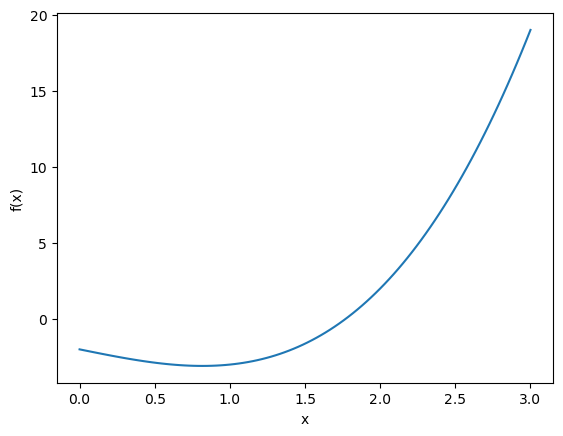

In [41]:
# plot f(x)  

import numpy as np
import matplotlib.pyplot as plt


# define function
def f(x):
    return x**3-2*x- 2  

xvalues = np.linspace(0,3,100)
yvalues = f(xvalues)

plt.plot(xvalues,yvalues)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

Newton's method requires us to choose an initial starting point $x$ and evaluate the derivative of the function at $x$. 

Already we see one downside to this method. You need to be able to calculate the derivative of the function. However, if you can't do it analytically, perhaps you are working with numerical data, you can still calculate it numerically. (Note this is a variant of this method called the secant method, which we won't cover, that doesn't require evaluation of the derivative.)

We use the derivative to estimate where the root is. We then calculate the derivative at the new estimate, to get a new estimate, one that we hope will be closer to the true root. We continue iterating until we reach our desired target accuracy.

Let's see how this works.


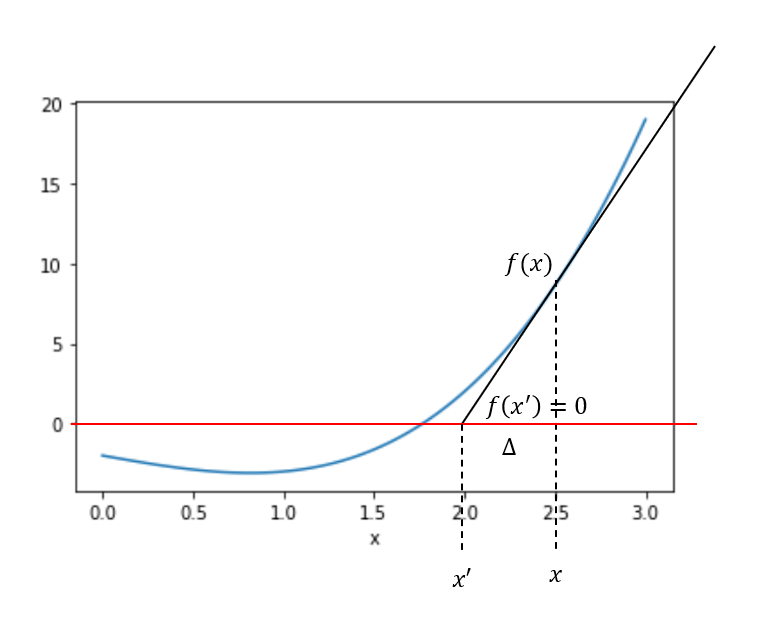


We'll choose a starting point of x=2.5. 


We calculate the derivative of $f(x)$ at 2.5, then we use the derivative to approximate where the root of $f(x)$ lies, i.e. where $f(x)=0$.  Basically, we extrapolate the slope at $x=2.5$ to $y=0$ and get the value of $x$ where the extrapolated line crosses the $y=0$ line, call that point $x'$.

$x'$ is mathematically given by:

$$ 
x' = x - \Delta. 
$$

We want to write $\Delta$ in terms of the derivative, so we first write the derivative $f'(x)$ as a backwards difference calculated with step size $\Delta$:

$$
f'(x)=\frac{f(x)-f(x')}{\Delta},
$$

so

$$
\Delta = \frac{f(x)-f(x')}{f'(x)},
$$

and substituting $\Delta$ above, we get:

$$
x'=x- \frac{f(x)-f(x')}{f'(x)}.
$$


Since $f(x')=0$ (by definition it crosses $y=0$ at $x=x'$), 

$$ 
x' = x - \frac{f(x)}{f'(x)}
$$

If we got lucky with our initial guess of $x$, $x'$ will be closer to the true root than $x$. We can then repeat this process, calculating the new derivative at $x'$, and then calculate the new estimate of $x'$ for the new iteration.

This second iteration is illustrated below.



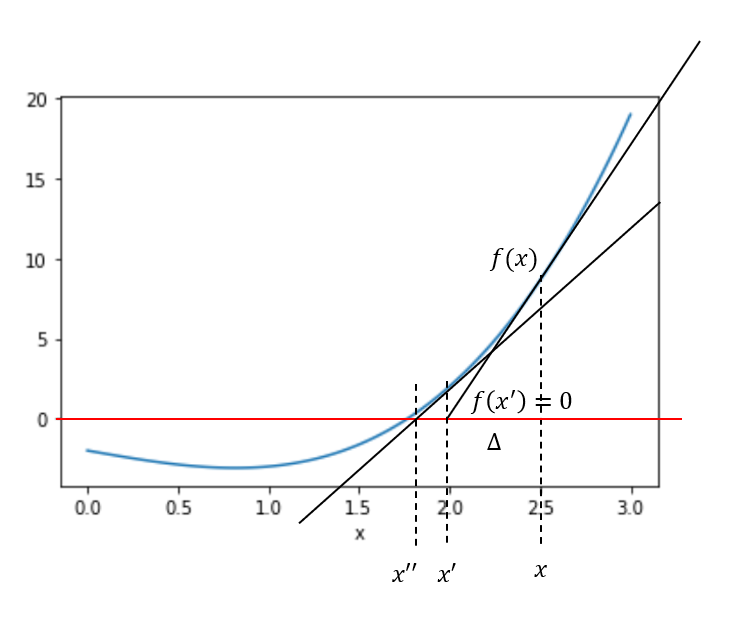

$x''$ is the estimate of the root for the second iteration of Newton's method. We see it is now very close to the true root. 

You can see that only after 2 iterations, we are already close to the true root. 

Newton's method converges quickly. If the error on one step of the method is $\epsilon$, the error on the next step will be $\sim$ $\epsilon^2$.  It can be shown (see textbook) that the estimate converges so quickly, and the improvement on the next estimate is so good, that the next estimate is about equal to the true root. So the error on the previous iteration can be estimated as:

$$
\epsilon = x'-x.
$$

That is, the error is just the change in $x$ from one iteration to the next (similar to how we estimated the error of Gaussian quadrature). Note this is the error on $x$ not $x'$. In order to calculate the error on $x'$ we need to iterate again.

Let's think about the pseudocode for Newton's method.

1. Choose an initial estimate of the root and a target accuracy.
2. Calculate the derivative of $f(x)$ at $x$ and use it to calculate the next estimate $x'$.
3. Calculate the error on $x$ using $\epsilon = x'-x$. 
4. If the error is larger than the target accuracy use new estimate $x'$ and repeat steps 2-4.

### Practice exercise: Newton's method

Use Newton's method to find the roots of 


$
f(x) = x^3-2x-2
$

In [ ]:
# use newton's method to find the root for a given function

def f(x):
    return x**3 -2*x-2

def newton(f, x):
    
    


The estimate of the root is 3.452054794520548 +/ 1.547945205479452 after 1 iterations
The estimate of the root is 2.4970063236984767 +/ 0.9550484708220712 after 2 iterations
The estimate of the root is 1.983695301881014 +/ 0.5133110218174628 after 3 iterations
The estimate of the root is 1.7961871656003479 +/ 0.1875081362806661 after 4 iterations
The estimate of the root is 1.7697974105290193 +/ 0.02638975507132857 after 5 iterations
The estimate of the root is 1.7692925373241306 +/ 0.0005048732048886784 after 6 iterations
The estimate of the root is 1.7692923542386554 +/ 1.8308547522494223e-07 after 7 iterations
The estimate of the root is 1.7692923542386314 +/ 2.398081733190338e-14 after 8 iterations
The estimate of the root is 1.7692923542386314 +/ 0.0 after 9 iterations


Pretty good. We find the root with an accuracy down to numerical precision after only 9 iterations. This illustrates how quickly Newton's method converges.

What happens if we don't choose a very good estimate for the starting point? Will we still converge on the root? 

Well let's see what happens here when we use Newton's method to solve for the roots of this function

$
x^3-9x+20.
$


Text(0.5, 0, 'x')

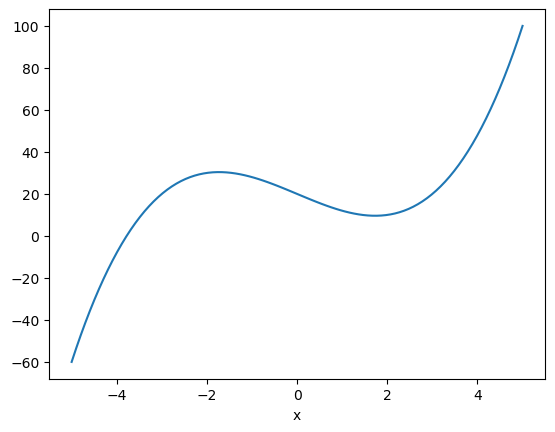

In [43]:
# plot f(x)  

import numpy as np
import matplotlib.pyplot as plt


# define function
def f(x):
    return x**3-9*x+20.

xvalues = np.linspace(-5,5,100)
yvalues = f(xvalues)

plt.plot(xvalues,yvalues)
plt.xlabel("x")

Clearly we see the root is around -4. But let's use x=1 as our starting guess, in the well of the function where the derivative actually will push us initially away from the root.

In [43]:
# use newton's method to find the root for a given function

import numpy as np
import matplotlib as plt


    

The root is 3.0 +/ 2.0 after 1 iterations
The root is 1.8888888888888888 +/ 1.1111111111111112 after 2 iterations
The root is -3.827697262479876 +/ 5.716586151368765 after 3 iterations
The root is -3.7810260358948056 +/ 0.04667122658507061 after 4 iterations
The root is -3.7802909526242634 +/ 0.0007350832705421695 after 5 iterations
The root is -3.7802907716830116 +/ 1.8094125175949216e-07 after 6 iterations
The root is -3.7802907716830005 +/ 1.1102230246251565e-14 after 7 iterations
The root is -3.7802907716830005 +/ 0.0 after 8 iterations


Newton's method is quite robust for this function. We can choose obviously bad starting points and the method still converges on the solution. Unfortunately that won't be the case for all functions, but compared to the relaxation method, Newton's method will converge on more functions.

Finally, we should point out that just like binary search, Newton's method will find only one root, even if there are more. So if you want to find more roots, you will need to move your starting estimate closer to the root. 